# Parameter Optimization 
**Objective**: Automatically find the optimal values of the controllable parameters that minimize the `Cost`.

Let $\theta = (\mu, \sigma, \theta, \text{inspection\_deviation}, \text{inspection\_threshold}) \in \mathbb{R}^5$ be the vector of controllable parameters.

1. **Cost Function $C(\theta)$**:
* $C(\theta)$ is the cost computed from a unique simulation $$C(\theta) = w_1 \times c_1 + w_2 \times c_2$$.
* As the simulation is random, the true objective is : $$\bar{C}(\theta) = \mathbb{E}[C(\theta)]$$

2. **Is the objective differentiable ?**
* Discrete decision events
   * Replacement decisions are binary : `age_beta > threshold` or `cdf > threshold`
   * Expiration check : `age >= expiration`
* Stochastic jumps
   * Random draws cause discrete changes in event sequences (failure vs. no failure, replacement vs. no replacement).
* Non-smooth transformations
   * The cost is a sum over discrete events (inspections, replacements, failures), each triggered by inequalities, thus, the overall mapping $\theta \mapsto C(\theta)$ is piecewise constant or has kinks.
  
Because of these discontinuities and non-smoothness, **no analytical gradient** exists.

In [5]:
import numpy as np

In [6]:
from pipmcm2d import compute_cost, algorithme_genetique

##  Reproducibility and noise reduction

### Single global seed (clarity requirement)
To ensure reproducibility, we define **one global seed once** at the top and derive all randomness from it.

This guarantees:
- same initial population,
- same selection/crossover/mutation decisions,
- and controlled Monte-Carlo scenarios.

### Common Random Numbers (CRN)
To compare individuals fairly, all individuals in the same generation are evaluated using the **same Monte-Carlo seeds**.

This reduces noise in comparisons because differences between candidates are due mainly to parameters, not random chance.

## 1. Monte-Carlo estimation of the cost

Since the simulator contains random draws, the observed cost varies across runs even for the same parameters.

We approximate the expected cost with Monte-Carlo:

$
\hat{C}(\theta)=\frac{1}{M}\sum_{i=1}^{M} C_i(\theta)
$

- Increasing \(M\) makes the estimate more stable (variance decreases roughly as $\frac{1}{M}$),
- but increases computational time.

### Risk-sensitive objective

In addition to the mean cost, we may penalize high variability (risk).  
We use a mean-variance style objective:

$$
J(\theta) = \mathbb{E}[C(\theta)] + \alpha \cdot \mathrm{Std}(C(\theta))
$$

With $\alpha \cdot \mathrm{Std}(C(\theta)$ to penalize the variation
- $\alpha$ is a tunable risk weight (`alpha_std` in the code).

##  Cost function implementation (`compute_cost`)

The function `compute_cost`:

- builds the parameter dictionary expected by the simulator.
- runs the simulation $M$ times using a provided list of seeds.
- extracts KPIs.
- returns the average cost plus a risk penalty.

Key points:
- **No random seed is generated inside the function** for reproducibility.
- The KPI keys are explicitly used:
  - `"Total average cost of one system"`
  - `"Standard Deviation"`
- A penalty of `1e12` is returned if the simulation produces invalid KPIs.

In [7]:
# from pipmcm2d import compute_cost

## 2. Why a Genetic Algorithm (GA)?

As discussed in the beginning he mapping \(\theta \mapsto C(\theta)\) produced by the simulator is typically:

- non-linear.
- non-convex.
- not differentiable (discrete events, thresholds).
- and noisy (stochastic simulation).

For these reasons, gradient-based methods are not reliable.  
A **Genetic Algorithm** is a good choice because it is:

- derivative-free.
- global (population-based exploration).
- robust to noise (especially with validation strategies like the one used here).

## 3. Genetic Algorithm: detailed mechanism

This algorithm is inspired by the human biology and reproduction.

A GA maintains a **population** of candidate solutions. Each candidate is an "individual" whose "chromosome" is the vector $\theta$.

### 3.1 Population initialization
We generate $N$ individuals uniformly in the parameter bounds.

### 3.2 Fitness evaluation
Each individual is evaluated with a fitness function.  
Here, fitness = **estimated cost**, so lower is better.

### 3.3 Selection (Tournament selection)
To create offspring, we choose parents using tournament selection:

1. randomly pick `tournoi_k` individuals,
2. choose the best (lowest cost) among them.

- Small `tournoi_k` $\rightarrow$ more exploration
- Large `tournoi_k` $\rightarrow$ faster convergence but higher risk of premature convergence.

### 3.4 Crossover (Uniform crossover)
Given two parents, the child is built by mixing parameters:

- for each dimension $j$, the child inherits gene $j$ from parent 1 or parent 2 with probability 0.5.

### 3.5 Mutation (Gaussian mutation)
After crossover, each gene can mutate:

$$
\theta_j \leftarrow \theta_j + \mathcal{N}(0,\ \sigma_{\text{mutation}} \cdot (b_j^{max}-b_j^{min}))
$$

Then we clamp the value to remain within bounds.

### 3.6 Elitism
The best `elitisme` individuals (the ones who minimize the cost) are copied unchanged into the next generation, ensuring we never lose top solutions.

### 3.7 Immigration (diversity injection)
To prevent stagnation, we replace a fraction of the population with new random individuals each generation.

This maintains diversity and helps escape local optima.

### 3.8 Early stopping
If no validated improvement occurs for `patience` generations, we stop to save computation time.

## 4. Genetic Algorithm implementation (`algorithme_genetique`)

The GA is implemented with two evaluation levels:

- **Fast evaluation** (`M_test`): used to evaluate the entire population quickly.
- **Validation evaluation** (`M_validate`): used to evaluate the best candidate more reliably.

### Why two levels?
- If we only used a small $M$, the GA could optimize *noise* (lucky runs).  
- And with a large $M$, the optimisation is costly.

To prevent this, we **update the global best only when the validated score improves**.

### Outputs
The GA returns:
- `meilleur_theta`: best parameters found (validated)
- `meilleur_cout_valid`: validated best cost
- `hist_best_fast`: best fast cost per generation
- `hist_mean_fast`: mean fast cost per generation
- `hist_best_valid`: validated cost of the best candidate per generation

In [8]:
# from pipmcm2d import algorithme_genetique

In [9]:
fixed_param = {
    "eta": 720,
    "beta": 3,
    "expiration": 900,
    "r": 0.0005,
    "nu": 0.00005
}

costs = {
    "replacement": 1000,
    "inspection": 100 ,
    "component": 100,
    "failure": 1200 
}

# Initital parameters
theta_init = np.array([
    350.0,    # mu           
    40.0,     # sigma
    25.0,     # theta_rempl
    0.12,     # inspection_deviation   
    0.40      # inspection_threshold
])

bornes = [
    [150, 600],       # mu
    [20, 80],         # sigma
    [10, 40],         # theta
    [0.05, 0.90],     # deviation 
    [0.05, 0.95]      # threshold
]

In [10]:
GLOBAL_SEED = 1234
rng = np.random.default_rng(GLOBAL_SEED)

meilleur_theta, meilleur_cout, hist_best, hist_mean, hist_valid = algorithme_genetique(
    fixed_param=fixed_param,
    costs=costs,
    bornes=bornes,
    rng=rng,                 
    taille_pop=15,
    max_generation=30,
    M_test=3,
    M_validate=20
)

génération |    Best_fast |    Mean_fast |   Best_valid


         1 |     64720.87 |     69756.83 |     68074.81
         2 |     64753.58 |     70529.30 |     65437.63
         3 |     64493.02 |     69796.88 |     67985.28
         4 |     61817.82 |     68141.77 |     64583.43
         5 |     61173.97 |     68462.26 |     64536.39
         6 |     57169.47 |     65523.24 |     60964.64
         7 |     57927.77 |     65531.87 |     64044.61
         8 |     57228.46 |     66519.34 |     59782.64
         9 |     60634.16 |     66986.45 |     65251.89
        10 |     60990.36 |     67203.46 |     60076.93
        11 |     59190.33 |     65081.37 |     61292.53
        12 |     57732.91 |     64782.45 |     63208.68
        13 |     58248.16 |     65014.93 |     62217.60
        14 |     60005.84 |     66556.90 |     63644.11
        15 |     58044.48 |     67800.93 |     59928.02
        16 |     59471.14 |     64713.65 |     63278.05
Arret anticipé: aucune amélioration (Validée) depuis 8 générations.


In [11]:
seeds_eval = rng.integers(0, 2**31 - 1, size=20, dtype=np.int64)

c_init = compute_cost(theta_init, fixed_param, costs, M=20, seeds=seeds_eval)
c_best = compute_cost(meilleur_theta, fixed_param, costs, M=20, seeds=seeds_eval)

print(f"{c_init} | {c_best}| {c_init - c_best}")

68797.63759999999 | 61495.802599999995| 7301.834999999992


In [12]:
meilleur_theta

array([220.75056424,  57.69191617,  28.29674698,   0.9       ,
         0.95      ])

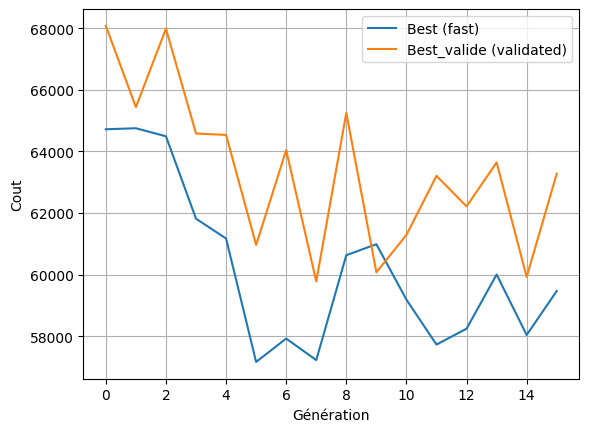

In [13]:
import matplotlib.pyplot as plt 

plt.figure()
plt.plot(hist_best, label = "Best (fast)")
plt.plot(hist_valid, label = "Best_valide (validated)")
plt.xlabel("Génération")
plt.ylabel("Cout")
plt.legend()
plt.grid(True)
plt.show()